In [47]:
!nvidia-smi

Fri Oct  3 10:52:45 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P0             28W /   70W |     798MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [48]:
%cd /content
!pwd

!git clone https://github.com/amazon-science/patchcore-inspection.git

%cd patchcore-inspection
!pwd

import sys
import os
sys.path.append(os.getcwd())

/content
/content
fatal: destination path 'patchcore-inspection' already exists and is not an empty directory.
/content/patchcore-inspection
/content/patchcore-inspection


In [49]:
!pip install -e .

!pip install -r requirements.txt


Obtaining file:///content/patchcore-inspection
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for patchcore (pyproject.toml) ... done
  Created wheel for patchcore: filename=patchcore-0.1.0-0.editable-py3-none-any.whl size=5413 sha256=215f3fb8753ce468e8e29acb13279fb48c2b45427ad31571de73953766d0eccf
  Stored in directory: /tmp/pip-ephem-wheel-cache-dsld6u_y/wheels/13/84/90/2078bceee367794093d2777653873faefff51259ca2d4bf9b4
Successfully built patchcore
  Attempting uninstall: patchcore
    Found existing installation: patchcore 0.1.0
    Uninstalling patchcore-0.1.0:
      Successfully uninstalled patchcore-0.1.0


In [50]:
%cd /content
!mkdir -p datasets/MVTec
%cd datasets/MVTec

!wget https://www.mydrive.ch/shares/38536/3830184030e49fe74747669442f0f282/download/420938130-1629953152/screw.tar.xz
!tar -xvf screw.tar.xz

!ls -l
!ls -l screw/

/content
/content/datasets/MVTec
--2025-10-03 10:53:04--  https://www.mydrive.ch/shares/38536/3830184030e49fe74747669442f0f282/download/420938130-1629953152/screw.tar.xz
Resolving www.mydrive.ch (www.mydrive.ch)... 91.214.169.64
Connecting to www.mydrive.ch (www.mydrive.ch)|91.214.169.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 195344332 (186M) [application/x-xz]
Saving to: ‘screw.tar.xz.1’

screw.tar.xz.1      100%[===================>] 186.29M  21.0MB/s    in 10s     

2025-10-03 10:53:15 (18.4 MB/s) - ‘screw.tar.xz.1’ saved [195344332/195344332]

screw/
screw/ground_truth/
screw/ground_truth/manipulated_front/
screw/ground_truth/manipulated_front/013_mask.png
screw/ground_truth/manipulated_front/014_mask.png
screw/ground_truth/manipulated_front/015_mask.png
screw/ground_truth/manipulated_front/016_mask.png
screw/ground_truth/manipulated_front/017_mask.png
screw/ground_truth/manipulated_front/018_mask.png
screw/ground_truth/manipulated_front/019_mask.

In [51]:
%%bash
set -e
cd /content

rm -rf patchcore-inspection
git clone --depth 1 --branch main https://github.com/amazon-science/patchcore-inspection.git


ls -la patchcore-inspection | sed -n '1,200p'
echo "---- src 内容 ----"
ls -la patchcore-inspection/src | sed -n '1,200p'


total 116
drwxr-xr-x 8 root root  4096 Oct  3 10:53 .
drwxr-xr-x 1 root root  4096 Oct  3 10:53 ..
drwxr-xr-x 2 root root  4096 Oct  3 10:53 bin
-rw-r--r-- 1 root root   309 Oct  3 10:53 CODE_OF_CONDUCT.md
-rw-r--r-- 1 root root  3160 Oct  3 10:53 CONTRIBUTING.md
drwxr-xr-x 9 root root  4096 Oct  3 10:54 .git
-rw-r--r-- 1 root root    86 Oct  3 10:53 .gitattributes
-rw-r--r-- 1 root root    44 Oct  3 10:53 .gitignore
drwxr-xr-x 2 root root  4096 Oct  3 10:53 images
-rw-r--r-- 1 root root 10142 Oct  3 10:53 LICENSE
-rwxr-xr-x 1 root root   160 Oct  3 10:53 local_run_test.sh
drwxr-xr-x 8 root root  4096 Oct  3 10:53 models
-rw-r--r-- 1 root root    67 Oct  3 10:53 NOTICE
-rw-r--r-- 1 root root   169 Oct  3 10:53 pyproject.toml
-rw-r--r-- 1 root root  9595 Oct  3 10:53 README.md
-rw-r--r-- 1 root root    76 Oct  3 10:53 requirements_dev.txt
-rw-r--r-- 1 root root   222 Oct  3 10:53 requirements.txt
-rw-r--r-- 1 root root   801 Oct  3 10:53 sample_evaluation.sh
-rw-r--r-- 1 root root  4948

Cloning into 'patchcore-inspection'...
Filtering content: 100% (360/360), 2.14 GiB | 36.39 MiB/s, done.


In [52]:
%%bash
export OMP_NUM_THREADS=2
export MKL_NUM_THREADS=2


In [53]:
%%bash
set -e
cd /content/patchcore-inspection

python3 --version

PYTHONPATH=src python3 bin/run_patchcore.py \
  --gpu 0 --seed 0 --save_patchcore_model \
  --log_group IM224_WR50_L2_3_P01_D1024_1024_PS_3_AN_1_S0 results \
  patch_core -b wideresnet50 -le layer2 -le layer3 \
  --pretrain_embed_dimension 1024 --target_embed_dimension 1024 \
  --anomaly_scorer_num_nn 1 --patchsize 3 \
  sampler -p 0.1 approx_greedy_coreset \
  dataset --resize 256 --imagesize 224 -d screw mvtec /content/datasets/MVTec

Python 3.12.11


INFO:__main__:Command line arguments: bin/run_patchcore.py --gpu 0 --seed 0 --save_patchcore_model --log_group IM224_WR50_L2_3_P01_D1024_1024_PS_3_AN_1_S0 results patch_core -b wideresnet50 -le layer2 -le layer3 --pretrain_embed_dimension 1024 --target_embed_dimension 1024 --anomaly_scorer_num_nn 1 --patchsize 3 sampler -p 0.1 approx_greedy_coreset dataset --resize 256 --imagesize 224 -d screw mvtec /content/datasets/MVTec
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
INFO:__main__:Evaluating dataset [mvtec_screw] (1/1)...
/usr/local/lib/python3.12/dist-packages/torchvision/models/_ut

In [54]:

import os, glob, pprint

repo_dir = "/content/patchcore-inspection"
cands = sorted(
    glob.glob(os.path.join(repo_dir, "results", "**", "models", "mvtec_screw*"), recursive=True),
    key=os.path.getmtime, reverse=True
)
assert cands, "没有找到模型（results/**/models/mvtec_screw*）。请确认训练时加了 --save_patchcore_model。"
model_dir = cands[0]
print("✅ Using model_dir =", model_dir)


out_dir = os.path.join(repo_dir, "evaluated_results", "screw_run")
os.makedirs(out_dir, exist_ok=True)
print("🗂️  Images will be saved to:", out_dir)


✅ Using model_dir = /content/patchcore-inspection/results/project/IM224_WR50_L2_3_P01_D1024_1024_PS_3_AN_1_S0/models/mvtec_screw
🗂️  Images will be saved to: /content/patchcore-inspection/evaluated_results/screw_run


In [55]:
%%bash
cd /content/patchcore-inspection

python3 - <<'PY'
import re, sys, pathlib
p = pathlib.Path("src/patchcore/datasets/mvtec.py")
src = p.read_text()

pattern = r"(class\s+MVTecDataset\(.*?\):.*?def\s+__init__\s*\(.*?\):)(.*?)(\n\s*def\s)"
m = re.search(pattern, src, flags=re.S|re.M)
if not m:
    print("[ERR] 未找到 MVTecDataset.__init__，请检查文件路径")
    sys.exit(1)

head, body, tail = m.groups()
inject = """
        # ---- injected fallback for transform stats (if missing) ----
        if not hasattr(self, 'transform_mean'):
            self.transform_mean = [0.485, 0.456, 0.406]
        if not hasattr(self, 'transform_std'):
            self.transform_std = [0.229, 0.224, 0.225]
        # -------------------------------------------------------------
"""

if "transform_std" not in body and "transform_mean" not in body:
    new_body = body + inject
    new_src = src[:m.start(2)] + new_body + src[m.end(2):]
    p.write_text(new_src)
    print("[OK] Patched mvtec.py: added default transform_mean/std.")
else:
    print("[SKIP] Already has transform_mean/std.")
PY


[OK] Patched mvtec.py: added default transform_mean/std.


In [56]:
%cd /content/patchcore-inspection
!PYTHONPATH=src python3 bin/load_and_evaluate_patchcore.py \
  --gpu 0 --seed 0 --save_segmentation_images \
  /content/patchcore-inspection/evaluated_results/screw_run \
  patch_core_loader -p /content/patchcore-inspection/results/project/IM224_WR50_L2_3_P01_D1024_1024_PS_3_AN_1_S0_1/models/mvtec_screw \
  dataset --resize 256 --imagesize 224 -d screw mvtec /content/datasets/MVTec


/content/patchcore-inspection
INFO:__main__:Command line arguments: bin/load_and_evaluate_patchcore.py --gpu 0 --seed 0 --save_segmentation_images /content/patchcore-inspection/evaluated_results/screw_run patch_core_loader -p /content/patchcore-inspection/results/project/IM224_WR50_L2_3_P01_D1024_1024_PS_3_AN_1_S0_1/models/mvtec_screw dataset --resize 256 --imagesize 224 -d screw mvtec /content/datasets/MVTec
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
INFO:__main__:Evaluating dataset [mvtec_screw] (1/1)...
Traceback (most recent call last):
  File "/content/patchcore-inspection/bin

In [57]:
import os, re, subprocess, shlex, json, textwrap

repo = "/content/patchcore-inspection"
help_cmd = f"PYTHONPATH={shlex.quote(os.path.join(repo,'src'))} python3 {shlex.quote(os.path.join(repo,'bin','load_and_evaluate_patchcore.py'))} --help"
print("[RUN]", help_cmd)
res = subprocess.run(["bash","-lc", help_cmd], capture_output=True, text=True)
help_text = res.stdout + "\n" + res.stderr
print(help_text[:800])

save_flags = sorted(set(re.findall(r"(--save[-_\w]+)", help_text)))

preferred = ["--save_segmentation_images","--save_images","--save_anomaly_maps","--save_gallery"]
save_flags = [f for f in preferred if f in save_flags] + [f for f in save_flags if f not in preferred]

print("\n[Detected save flags]", save_flags)


[RUN] PYTHONPATH=/content/patchcore-inspection/src python3 /content/patchcore-inspection/bin/load_and_evaluate_patchcore.py --help
Usage: load_and_evaluate_patchcore.py [OPTIONS] RESULTS_PATH COMMAND1
                                      [ARGS]... [COMMAND2 [ARGS]...]...

Options:
  --gpu INTEGER               [default: 0]
  --seed INTEGER              [default: 0]
  --save_segmentation_images
  --help                      Show this message and exit.

Commands:
  dataset
  patch_core_loader

INFO:__main__:Command line arguments: /content/patchcore-inspection/bin/load_and_evaluate_patchcore.py --help


[Detected save flags] ['--save_segmentation_images']


In [59]:
import subprocess, shlex, os, textwrap

repo = "/content/patchcore-inspection"
save_dir = "/content/patchcore-inspection/evaluated_results/screw_run"
model_dir = "/content/patchcore-inspection/results/project/IM224_WR50_L2_3_P01_D1024_1024_PS_3_AN_1_S0_1/models/mvtec_screw"
data_root = "/content/datasets/MVTec"

save_flags = globals().get("save_flags", [])
flags_str = " ".join(save_flags)

cmd = (
  f"PYTHONPATH={shlex.quote(os.path.join(repo,'src'))} "
  f"python3 {shlex.quote(os.path.join(repo,'bin','load_and_evaluate_patchcore.py'))} "
  f"--gpu 0 --seed 0 {flags_str} "
  f"{shlex.quote(save_dir)} "
  f"patch_core_loader -p {shlex.quote(model_dir)} "
  f"dataset --resize 256 --imagesize 224 -d screw mvtec {shlex.quote(data_root)}"
)

print("[RUN]", cmd)
ret = subprocess.run(["bash","-lc", cmd], text=True, capture_output=True)
print(ret.stdout)
if ret.returncode != 0:
    print(ret.stderr)
    raise SystemExit("评测失败（看上面的 stderr）。")


[RUN] PYTHONPATH=/content/patchcore-inspection/src python3 /content/patchcore-inspection/bin/load_and_evaluate_patchcore.py --gpu 0 --seed 0 --save_segmentation_images /content/patchcore-inspection/evaluated_results/screw_run patch_core_loader -p /content/patchcore-inspection/results/project/IM224_WR50_L2_3_P01_D1024_1024_PS_3_AN_1_S0_1/models/mvtec_screw dataset --resize 256 --imagesize 224 -d screw mvtec /content/datasets/MVTec

INFO:__main__:Command line arguments: /content/patchcore-inspection/bin/load_and_evaluate_patchcore.py --gpu 0 --seed 0 --save_segmentation_images /content/patchcore-inspection/evaluated_results/screw_run patch_core_loader -p /content/patchcore-inspection/results/project/IM224_WR50_L2_3_P01_D1024_1024_PS_3_AN_1_S0_1/models/mvtec_screw dataset --resize 256 --imagesize 224 -d screw mvtec /content/datasets/MVTec
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our su

SystemExit: 评测失败（看上面的 stderr）。

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [60]:
%cd /content/patchcore-inspection
!PYTHONPATH=src python3 bin/load_and_evaluate_patchcore.py \
  --gpu 0 --seed 0 \
  --save_segmentation_images \
  /content/patchcore-inspection/evaluated_results/screw_run \
  patch_core_loader -p /content/patchcore-inspection/results/project/IM224_WR50_L2_3_P01_D1024_1024_PS_3_AN_1_S0_1/models/mvtec_screw \
  dataset --resize 256 --imagesize 224 -d screw mvtec /content/datasets/MVTec


/content/patchcore-inspection
INFO:__main__:Command line arguments: bin/load_and_evaluate_patchcore.py --gpu 0 --seed 0 --save_segmentation_images /content/patchcore-inspection/evaluated_results/screw_run patch_core_loader -p /content/patchcore-inspection/results/project/IM224_WR50_L2_3_P01_D1024_1024_PS_3_AN_1_S0_1/models/mvtec_screw dataset --resize 256 --imagesize 224 -d screw mvtec /content/datasets/MVTec
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
INFO:__main__:Evaluating dataset [mvtec_screw] (1/1)...
Traceback (most recent call last):
  File "/content/patchcore-inspection/bin

In [61]:
import os, glob, cv2, matplotlib.pyplot as plt
root = "/content/patchcore-inspection/evaluated_results/screw_run"
pats = ["**/*heatmap*.png","**/*prediction*.png","**/*overlay*.png","**/*anomaly*.png","**/*result*.png","**/*seg*.png"]
hits = []
for pat in pats: hits += glob.glob(os.path.join(root, pat), recursive=True)
hits = sorted(set(hits), key=os.path.getmtime, reverse=True)
print(f"Found {len(hits)} images under {root}.")
for p in hits[:10]: print(" -", p)
if hits:
    img = cv2.imread(hits[0]); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title(os.path.basename(hits[0])); plt.show()
else:
    print("还是没有可视化图片；那就用方案 B 直接在 Notebook 里生成热力图。")


Found 0 images under /content/patchcore-inspection/evaluated_results/screw_run.
还是没有可视化图片；那就用方案 B 直接在 Notebook 里生成热力图。


[BANK] size=(15680, 1536) (N,C) stride=4
[FAISS] ntotal= 15680
[DONE] Saved 24 samples to: /content/patchcore-inspection/evaluated_results/screw_run/images/test


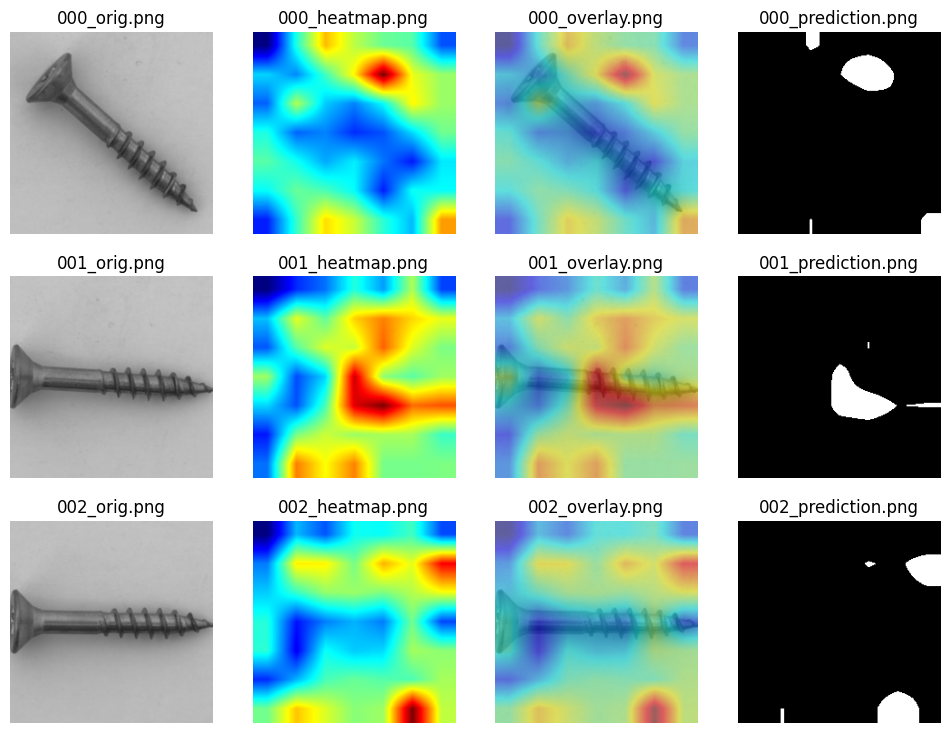

In [62]:

import os, glob, math, cv2, numpy as np
import torch, torchvision, torch.nn.functional as F
from torchvision import transforms
from pathlib import Path


DATA_ROOT   = "/content/datasets/MVTec"
CATEGORY    = "screw"          # 你的类
RESIZE      = 256              # --resize
IMGSIZE     = 224              # --imagesize
STRIDE      = 4                # 特征图采样步长(越小越细，越慢/越占内存)
MAX_TRAIN   = 999999           # 用多少张good训练图(默认全用)
MAX_TEST    = 24               # 先可视化多少张测试图(可调大/小)
TOPK        = 1                # 最近邻K(一致性起见保持1)
OUT_DIR     = "/content/patchcore-inspection/evaluated_results/screw_run/images/test"
os.makedirs(OUT_DIR, exist_ok=True)


try:
    import faiss
except Exception:
    import subprocess, sys
    print("[INFO] installing faiss-cpu ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "faiss-cpu"], check=True)
    import faiss


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
weights = torchvision.models.Wide_ResNet50_2_Weights.DEFAULT
backbone = torchvision.models.wide_resnet50_2(weights=weights).to(device).eval()

feat_maps = {}
def _hook(name):
    def fn(_, __, out): feat_maps[name] = out.detach()
    return fn
h2 = backbone.layer2.register_forward_hook(_hook("l2"))
h3 = backbone.layer3.register_forward_hook(_hook("l3"))

normalize = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
denorm    = transforms.Normalize(mean=[-m/s for m,s in zip([0.485,0.456,0.406],[0.229,0.224,0.225])],
                                 std=[1/s for s in [0.229,0.224,0.225]])
preproc = transforms.Compose([
    transforms.Resize((RESIZE, RESIZE)),
    transforms.CenterCrop(IMGSIZE),
    transforms.ToTensor(),
    normalize
])


def pil_from_cv(bgr):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return torchvision.transforms.functional.to_pil_image(rgb)

def extract_feature_grid(img_path):
    """返回 (C,Hf,Wf) 的特征图(拼接 layer2+layer3 并 L2 norm)。"""
    bgr = cv2.imread(img_path)
    if bgr is None: return None
    x = preproc(pil_from_cv(bgr)).unsqueeze(0).to(device)
    with torch.no_grad():
        _ = backbone(x)
        f2, f3 = feat_maps["l2"], feat_maps["l3"]   # (1,C,H,W)
        if f2.shape[-2:] != f3.shape[-2:]:
            f3 = F.interpolate(f3, size=f2.shape[-2:], mode="bilinear", align_corners=False)
        f = torch.cat([f2, f3], dim=1)              # (1,C2+C3,H,W)
        f = F.normalize(f, p=2, dim=1)              # 通道维归一化
        f = f.squeeze(0)                            # (C,H,W)
    return f, bgr

def grid_flatten(feat_CHW, stride=STRIDE):
    """将 (C,H,W) 采样后展平为 (N,C)，并返回采样后的网格尺寸 (Hs,Ws)。"""
    C,H,W = feat_CHW.shape
    f = feat_CHW[:, ::stride, ::stride]            # (C, Hs, Ws)
    Hs, Ws = f.shape[1], f.shape[2]
    return f.permute(1,2,0).reshape(-1, C).contiguous(), (Hs, Ws)

def upsample_to_image(amap_hw, target_hw):
    """把特征图尺度的 anomaly map 上采样到 IMGSIZE，再到原图大小。"""
    amap = torch.from_numpy(amap_hw).float()[None,None]  # (1,1,h,w)
    amap = F.interpolate(amap, size=(IMGSIZE, IMGSIZE), mode="bilinear", align_corners=False)
    return amap[0,0].cpu().numpy()

def colorize_and_overlay(orig_bgr, heatmap_01):
    """把 0-1 的 heatmap 上色并叠加到原图上。"""
    hm_uint8 = np.clip(heatmap_01*255, 0, 255).astype(np.uint8)
    hm_color = cv2.applyColorMap(hm_uint8, cv2.COLORMAP_JET)

    rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    pil = torchvision.transforms.functional.to_pil_image(rgb)
    base = transforms.Resize((RESIZE, RESIZE))(pil)
    base = transforms.CenterCrop(IMGSIZE)(base)
    base = np.array(base)[:,:,::-1]
    overlay = cv2.addWeighted(base, 0.5, hm_color, 0.5, 0)
    return hm_color, overlay

def minmax_norm(x):
    m, M = np.min(x), np.max(x)
    if M - m < 1e-12:
        return np.zeros_like(x)
    return (x - m) / (M - m)


train_dir = os.path.join(DATA_ROOT, CATEGORY, "train", "good")
train_imgs = sorted(glob.glob(os.path.join(train_dir, "*.png")) +
                    glob.glob(os.path.join(train_dir, "*.jpg")))
if MAX_TRAIN and len(train_imgs) > MAX_TRAIN:
    train_imgs = train_imgs[:MAX_TRAIN]
assert train_imgs, f"找不到训练图片: {train_dir}"

bank_chunks = []
feat_dim = None
for p in train_imgs:
    r = extract_feature_grid(p)
    if r is None:
        continue
    feat_CHW, _ = r
    vecs, _ = grid_flatten(feat_CHW, stride=STRIDE)
    if feat_dim is None: feat_dim = vecs.shape[1]
    bank_chunks.append(vecs.cpu())

bank = torch.cat(bank_chunks, dim=0).float().contiguous()
print(f"[BANK] size={tuple(bank.shape)} (N,C) stride={STRIDE}")


index = faiss.IndexFlatL2(feat_dim)
index.add(bank.numpy())
print("[FAISS] ntotal=", index.ntotal)

test_dir = os.path.join(DATA_ROOT, CATEGORY, "test")
test_imgs = sorted(glob.glob(os.path.join(test_dir, "*", "*.png")) +
                   glob.glob(os.path.join(test_dir, "*", "*.jpg")))
if not test_imgs:
    test_imgs = sorted(glob.glob(os.path.join(test_dir, "*.png")) +
                       glob.glob(os.path.join(test_dir, "*.jpg")))
assert test_imgs, f"找不到测试图片: {test_dir}"
if MAX_TEST and len(test_imgs) > MAX_TEST:
    test_imgs = test_imgs[:MAX_TEST]

saved = []
for idx, p in enumerate(test_imgs):
    r = extract_feature_grid(p)
    if r is None:
        continue
    feat_CHW, orig_bgr = r
    vecs, (Hs, Ws) = grid_flatten(feat_CHW, stride=STRIDE)
    D, I = index.search(vecs.cpu().numpy(), TOPK)
    d_min = D[:,0].reshape(Hs, Ws)


    amap_small = d_min
    amap_imgsz = upsample_to_image(amap_small, (IMGSIZE, IMGSIZE))
    amap_01 = minmax_norm(amap_imgsz)


    hm_color, overlay = colorize_and_overlay(orig_bgr, amap_01)


    thr = float(np.quantile(amap_01, 0.95))
    pred = (amap_01 >= thr).astype(np.uint8) * 255
    pred_color = cv2.cvtColor(pred, cv2.COLOR_GRAY2BGR)

    stem = Path(p).stem
    out_heat = os.path.join(OUT_DIR, f"{stem}_heatmap.png")
    out_pred = os.path.join(OUT_DIR, f"{stem}_prediction.png")
    out_ovly = os.path.join(OUT_DIR, f"{stem}_overlay.png")
    out_orig = os.path.join(OUT_DIR, f"{stem}_orig.png")


    cv2.imwrite(out_heat, hm_color)
    cv2.imwrite(out_pred, pred_color)
    cv2.imwrite(out_ovly, overlay)

    rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    pil = torchvision.transforms.functional.to_pil_image(rgb)
    base = transforms.CenterCrop(IMGSIZE)(transforms.Resize((RESIZE, RESIZE))(pil))
    cv2.imwrite(out_orig, cv2.cvtColor(np.array(base), cv2.COLOR_RGB2BGR))

    saved.append((out_heat, out_pred, out_ovly, out_orig))

print(f"[DONE] Saved {len(saved)} samples to: {OUT_DIR}")

try:
    import matplotlib.pyplot as plt
    show = []
    for group in saved[:3]:
        show += [group[3], group[0], group[2], group[1]]  # orig, heat, overlay, pred
    plt.figure(figsize=(12, 3*len(saved[:3])))
    for i, path in enumerate(show):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(len(show)//4, 4, i+1)
        plt.imshow(img); plt.axis('off'); plt.title(os.path.basename(path))
    plt.show()
except Exception as e:
    print("Preview skipped:", e)

h2.remove(); h3.remove()


In [68]:
import glob, os
test_imgs = glob.glob("/content/datasets/MVTec/screw/test/**/*.png", recursive=True)
print("total number of tested images:", len(test_imgs))


total number of tested images: 160


In [64]:
import os, glob, math, cv2, numpy as np
import torch, torchvision, torch.nn.functional as F
from torchvision import transforms
from pathlib import Path

DATA_ROOT   = "/content/datasets/MVTec"
CATEGORY    = "screw"          # 类别
RESIZE      = 256              # --resize
IMGSIZE     = 224              # --imagesize
STRIDE      = 4                # 特征采样步长(越小越细，越慢/越占内存)
TOPK        = 1                # 最近邻K
OUT_DIR     = "/content/patchcore-inspection/evaluated_results/screw_run/images/test"
os.makedirs(OUT_DIR, exist_ok=True)


try:
    import faiss
except Exception:
    import subprocess, sys
    print("[INFO] installing faiss-cpu ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "faiss-cpu"], check=True)
    import faiss


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
weights = torchvision.models.Wide_ResNet50_2_Weights.DEFAULT
backbone = torchvision.models.wide_resnet50_2(weights=weights).to(device).eval()

feat_maps = {}
def _hook(name):
    def fn(_, __, out): feat_maps[name] = out.detach()
    return fn
h2 = backbone.layer2.register_forward_hook(_hook("l2"))
h3 = backbone.layer3.register_forward_hook(_hook("l3"))

normalize = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
preproc = transforms.Compose([
    transforms.Resize((RESIZE, RESIZE)),
    transforms.CenterCrop(IMGSIZE),
    transforms.ToTensor(),
    normalize
])

def pil_from_cv(bgr):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return torchvision.transforms.functional.to_pil_image(rgb)

def extract_feature_grid(img_path):
    bgr = cv2.imread(img_path)
    if bgr is None: return None
    x = preproc(pil_from_cv(bgr)).unsqueeze(0).to(device)
    with torch.no_grad():
        _ = backbone(x)
        f2, f3 = feat_maps["l2"], feat_maps["l3"]   # (1,C,H,W)
        if f2.shape[-2:] != f3.shape[-2:]:
            f3 = F.interpolate(f3, size=f2.shape[-2:], mode="bilinear", align_corners=False)
        f = torch.cat([f2, f3], dim=1)              # (1,C2+C3,H,W)
        f = F.normalize(f, p=2, dim=1)
        f = f.squeeze(0)                            # (C,H,W)
    return f, bgr

def grid_flatten(feat_CHW, stride=STRIDE):
    C,H,W = feat_CHW.shape
    f = feat_CHW[:, ::stride, ::stride]            # (C,Hs,Ws)
    Hs, Ws = f.shape[1], f.shape[2]
    return f.permute(1,2,0).reshape(-1, C).contiguous(), (Hs, Ws)

def upsample_to_img(amap_hw):
    amap = torch.from_numpy(amap_hw).float()[None,None]  # (1,1,h,w)
    amap = F.interpolate(amap, size=(IMGSIZE, IMGSIZE), mode="bilinear", align_corners=False)
    return amap[0,0].cpu().numpy()

def colorize_and_overlay(orig_bgr, heatmap_01):
    hm_uint8 = np.clip(heatmap_01*255, 0, 255).astype(np.uint8)
    hm_color = cv2.applyColorMap(hm_uint8, cv2.COLORMAP_JET)

    rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    pil = torchvision.transforms.functional.to_pil_image(rgb)
    base = transforms.CenterCrop(IMGSIZE)(transforms.Resize((RESIZE, RESIZE))(pil))
    base = np.array(base)[:,:,::-1]  # back to BGR
    overlay = cv2.addWeighted(base, 0.5, hm_color, 0.5, 0)
    return hm_color, overlay

def minmax_norm(x):
    m, M = np.min(x), np.max(x)
    if M - m < 1e-12: return np.zeros_like(x)
    return (x - m) / (M - m)


train_dir = os.path.join(DATA_ROOT, CATEGORY, "train", "good")
train_imgs = sorted(glob.glob(os.path.join(train_dir, "*.png")) +
                    glob.glob(os.path.join(train_dir, "*.jpg")))
assert train_imgs, f"找不到训练图片: {train_dir}"

bank_chunks = []
feat_dim = None
for p in train_imgs:
    r = extract_feature_grid(p)
    if r is None: continue
    feat_CHW, _ = r
    vecs, _ = grid_flatten(feat_CHW, stride=STRIDE)   # (N,C)
    if feat_dim is None: feat_dim = vecs.shape[1]
    bank_chunks.append(vecs.cpu())

bank = torch.cat(bank_chunks, dim=0).float().contiguous()
print(f"[BANK] size={tuple(bank.shape)} (N,C), stride={STRIDE}")

index = faiss.IndexFlatL2(feat_dim)
index.add(bank.numpy())
print("[FAISS] ntotal=", index.ntotal)


test_dir = os.path.join(DATA_ROOT, CATEGORY, "test")
test_imgs = sorted(glob.glob(os.path.join(test_dir, "*", "*.png")) +
                   glob.glob(os.path.join(test_dir, "*", "*.jpg")))
if not test_imgs:
    test_imgs = sorted(glob.glob(os.path.join(test_dir, "*.png")) +
                       glob.glob(os.path.join(test_dir, "*.jpg")))
assert test_imgs, f"找不到测试图片: {test_dir}"

saved_count = 0
for p in test_imgs:
    r = extract_feature_grid(p)
    if r is None:
        continue
    feat_CHW, orig_bgr = r
    vecs, (Hs, Ws) = grid_flatten(feat_CHW, stride=STRIDE)   # (N,C)
    D, I = index.search(vecs.cpu().numpy(), TOPK)            # (N,K)
    d_min = D[:,0].reshape(Hs, Ws)

    amap_imgsz = upsample_to_img(d_min)
    amap_01 = minmax_norm(amap_imgsz)

    hm_color, overlay = colorize_and_overlay(orig_bgr, amap_01)


    thr = float(np.quantile(amap_01, 0.95))
    pred = (amap_01 >= thr).astype(np.uint8) * 255
    pred_color = cv2.cvtColor(pred, cv2.COLOR_GRAY2BGR)

    stem = Path(p).stem
    out_heat = os.path.join(OUT_DIR, f"{stem}_heatmap.png")
    out_pred = os.path.join(OUT_DIR, f"{stem}_prediction.png")
    out_ovly = os.path.join(OUT_DIR, f"{stem}_overlay.png")
    out_orig = os.path.join(OUT_DIR, f"{stem}_orig.png")


    cv2.imwrite(out_heat, hm_color)
    cv2.imwrite(out_pred, pred_color)
    cv2.imwrite(out_ovly, overlay)


    rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    pil = torchvision.transforms.functional.to_pil_image(rgb)
    base = transforms.CenterCrop(IMGSIZE)(transforms.Resize((RESIZE, RESIZE))(pil))
    cv2.imwrite(out_orig, cv2.cvtColor(np.array(base), cv2.COLOR_RGB2BGR))

    saved_count += 1

print(f"[DONE] 共保存 {saved_count} 张（每张含 orig/heatmap/overlay/pred 四个文件）到：{OUT_DIR}")

h2.remove(); h3.remove()


[BANK] size=(15680, 1536) (N,C), stride=4
[FAISS] ntotal= 15680
[DONE] 共保存 160 张（每张含 orig/heatmap/overlay/pred 四个文件）到：/content/patchcore-inspection/evaluated_results/screw_run/images/test


In [65]:
!ls -lh /content/patchcore-inspection/evaluated_results/screw_run/images/test | head -20


total 6.3M
-rw-r--r-- 1 root root  31K Oct  3 11:00 000_heatmap.png
-rw-r--r-- 1 root root  52K Oct  3 11:00 000_orig.png
-rw-r--r-- 1 root root  58K Oct  3 11:00 000_overlay.png
-rw-r--r-- 1 root root 1.3K Oct  3 11:00 000_prediction.png
-rw-r--r-- 1 root root  39K Oct  3 11:00 001_heatmap.png
-rw-r--r-- 1 root root  55K Oct  3 11:00 001_orig.png
-rw-r--r-- 1 root root  64K Oct  3 11:00 001_overlay.png
-rw-r--r-- 1 root root 1.2K Oct  3 11:00 001_prediction.png
-rw-r--r-- 1 root root  35K Oct  3 11:00 002_heatmap.png
-rw-r--r-- 1 root root  50K Oct  3 11:00 002_orig.png
-rw-r--r-- 1 root root  59K Oct  3 11:00 002_overlay.png
-rw-r--r-- 1 root root 1007 Oct  3 11:00 002_prediction.png
-rw-r--r-- 1 root root  36K Oct  3 11:00 003_heatmap.png
-rw-r--r-- 1 root root  53K Oct  3 11:00 003_orig.png
-rw-r--r-- 1 root root  62K Oct  3 11:00 003_overlay.png
-rw-r--r-- 1 root root 1.2K Oct  3 11:00 003_prediction.png
-rw-r--r-- 1 root root  33K Oct  3 11:00 004_heatmap.png
-rw-r--r-- 1 root ro

总共 overlay 图: 41


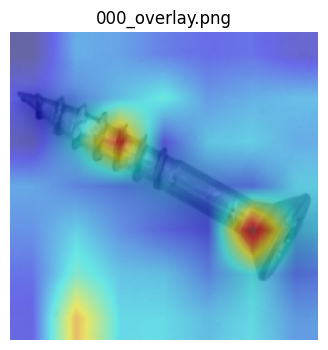

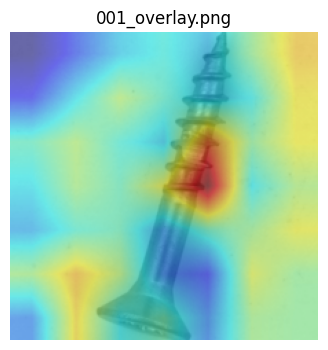

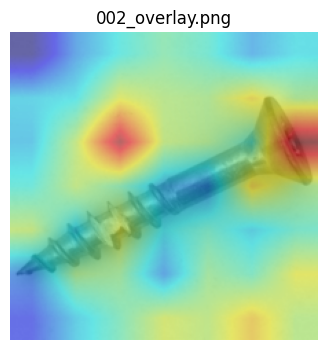

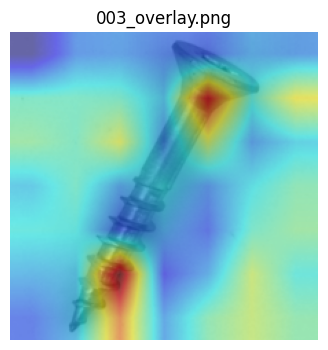

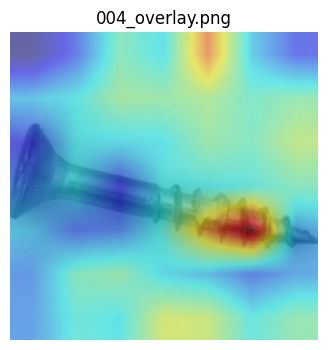

In [66]:
import matplotlib.pyplot as plt
import cv2, glob, os

img_dir = "/content/patchcore-inspection/evaluated_results/screw_run/images/test"
files = sorted(glob.glob(os.path.join(img_dir, "*_overlay.png")))

print("总共 overlay 图:", len(files))
for f in files[:5]:  # 显示前5张
    img = cv2.imread(f)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(os.path.basename(f))
    plt.axis("off")
    plt.show()


总共找到 orig: 41


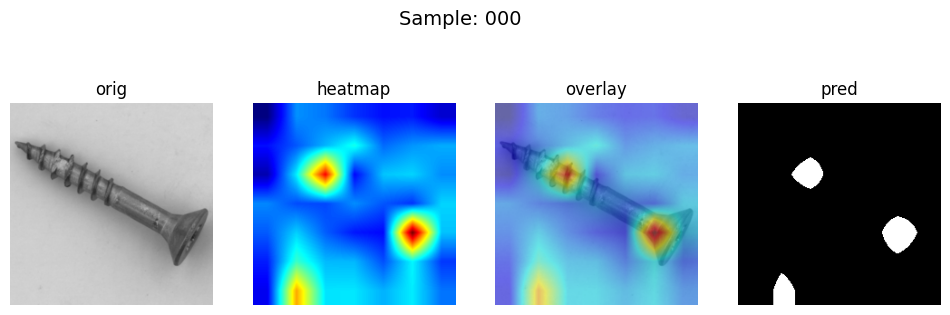

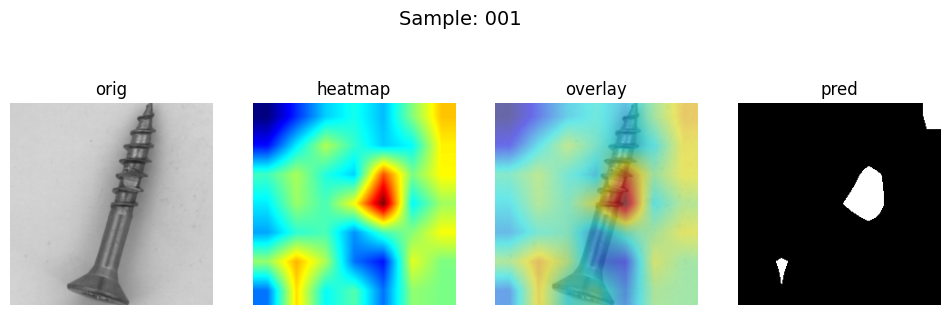

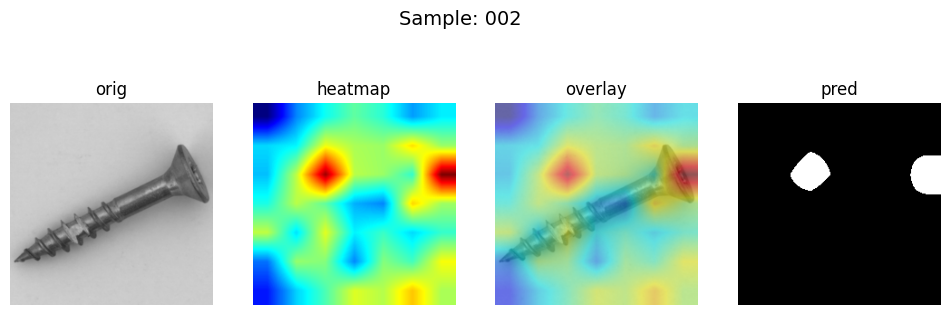

In [67]:
import matplotlib.pyplot as plt
import cv2, glob, os
from pathlib import Path

img_dir = "/content/patchcore-inspection/evaluated_results/screw_run/images/test"

def get_group(stem):
    return {
        "orig": os.path.join(img_dir, f"{stem}_orig.png"),
        "heatmap": os.path.join(img_dir, f"{stem}_heatmap.png"),
        "overlay": os.path.join(img_dir, f"{stem}_overlay.png"),
        "pred": os.path.join(img_dir, f"{stem}_prediction.png"),
    }

all_orig = sorted(glob.glob(os.path.join(img_dir, "*_orig.png")))
print("总共找到 orig:", len(all_orig))
samples = [Path(f).stem.replace("_orig","") for f in all_orig[:3]]  # 取前3个样例

for stem in samples:
    group = get_group(stem)
    plt.figure(figsize=(12,4))
    for i, (title, path) in enumerate(group.items()):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1,4,i+1)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")
    plt.suptitle(f"Sample: {stem}", fontsize=14)
    plt.show()
